# Optimized Cluster 4 — HPO + Retrain + Ablation

Notebook de contribution (préparation H1) :
1. **HPO** des hyperparamètres `TimeSeriesTransformer` sur le Cluster 4 (Optuna TPE, 15 trials)
2. **Retrain final** avec early stopping sur val R²
3. **Comparaison** vs baseline FAYAM
4. **Ablation per-function** : modèle dédié sur la fonction 949 (la plus problématique)

| Champ | Valeur |
|-------|--------|
| **Run** | `optimized-cluster4` |
| **Phase** | Phase 1 bis — HPO ciblée |
| **Cluster** | 4 (fonctions 949, 951, 952, 953, 954) |
| **Outil HPO** | Optuna TPE + MedianPruner |
| **Espace** | `d_model ∈ {32,64,128}`, `context_length ∈ {240,480,1440}`, `encoder_layers ∈ {2,3,4}`, `lr ∈ log[1e-5, 1e-3]` |
| **Fixés** | `n_heads=2`, `embedding_dim=2`, `dropout=0.1`, `batch_size=256`, `decoder=encoder` |
| **Validation** | 120 min held-out avant le test horizon |

> Avant de lancer : Runtime → Change runtime type → **T4 GPU**


## 1 — Setup

In [1]:
import subprocess
gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else 'Pas de GPU — vérifier le runtime.')

Thu May 14 15:42:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install -q transformers datasets "gluonts[torch]" accelerate evaluate scipy scikit-learn tqdm openpyxl ujson optuna

## 2 — Imports, seed et configuration

In [3]:
import random, os, json, gc
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache, partial
from tqdm.notebook import tqdm
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

SEED = 998
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Optuna  : {optuna.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
Optuna  : 4.8.0
Device  : cuda
GPU     : Tesla T4


In [4]:
# ── Hyperparams FIXÉS (non recherchés) ──────────────────────────
FREQ              = '1T'
PREDICTION_LENGTH = 120
N_HEADS           = 2
EMBEDDING_DIM     = [2]
DROPOUT           = 0.1
BATCH_SIZE_TRAIN  = 256
BATCH_SIZE_TEST   = 64
NUM_BATCHES_EPOCH = 100
BETAS             = (0.9, 0.95)
WEIGHT_DECAY      = 1e-1
GRAD_CLIP_NORM    = 1.0

# ── HPO config ──────────────────────────────────────────────────
HPO_N_TRIALS          = 15
HPO_EPOCHS            = 20
HPO_EVAL_EVERY        = 4
HPO_NUM_BATCHES_EPOCH = 50   # plus petit pour trials rapides

# ── Final retrain ───────────────────────────────────────────────
FINAL_MAX_EPOCHS = 80
FINAL_PATIENCE   = 10

CLUSTER_ID = 4
RUN_NAME   = f'optimized-cluster{CLUSTER_ID}'
print(f'Config OK — Cluster {CLUSTER_ID} | RUN_NAME={RUN_NAME}')

Config OK — Cluster 4 | RUN_NAME=optimized-cluster4


## 3 — Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = f'/content/drive/MyDrive/m2-xai-faas/experiments/{RUN_NAME}'
for subdir in ['checkpoints', 'results', 'attentions', 'hpo']:
    os.makedirs(f'{DRIVE_BASE}/{subdir}', exist_ok=True)
print(f'Dossier run : {DRIVE_BASE}')

Mounted at /content/drive
Dossier run : /content/drive/MyDrive/m2-xai-faas/experiments/optimized-cluster4


## 4 — Chargement du dataset (Cluster 4)

On construit **4 datasets** à partir des 5 séries du Cluster 4 :

| Dataset | Cible (target) | Usage |
|---------|---------------|-------|
| `hpo_train_dataset` | `target_full[:-240]` | Entraînement pendant HPO |
| `hpo_val_dataset`   | `target_full[:-120]` | Val R² pour HPO et early stopping (prédit positions -240 à -120) |
| `train_dataset`     | `target_full[:-120]` | Train final (= train baseline FAYAM) |
| `test_dataset`      | `target_full`        | Test final (prédit dernières 120 min) |


In [6]:
from pathlib import Path
from datasets import Dataset

try:
    from google.colab import drive as _drive  # noqa: F401
    DATA_DIR = Path('/content/drive/MyDrive/Recherche/Datasets')
except ImportError:
    DATA_DIR = Path('../../memoire/06-datasets/raw').resolve()

START_DATE = '2021-01-01 00:00:00'

df = pd.read_csv(DATA_DIR / f'cluster_{CLUSTER_ID}.csv', index_col='Function')
all_series = []
for func_id, row in df.iterrows():
    all_series.append({
        'function_id': int(func_id),
        'cluster':     CLUSTER_ID,
        'target_full': row.values.astype(np.float32),
    })

print(f'Cluster {CLUSTER_ID} — {len(all_series)} fonctions :')
for s in all_series:
    print(f"  function_id={s['function_id']}  longueur={len(s['target_full'])}  "
          f"moy={s['target_full'].mean():.0f}  max={s['target_full'].max():.0f}  min={s['target_full'].min():.0f}")

hpo_train_rows, hpo_val_rows, train_rows, test_rows = [], [], [], []
for ts_idx, s in enumerate(all_series):
    base = {
        'start':           START_DATE,
        'feat_static_cat': [ts_idx],
        'cluster':         s['cluster'],
        'function_id':     s['function_id'],
    }
    hpo_train_rows.append({**base, 'target': s['target_full'][:-2 * PREDICTION_LENGTH].tolist()})
    hpo_val_rows.append(  {**base, 'target': s['target_full'][:-PREDICTION_LENGTH].tolist()})
    train_rows.append(    {**base, 'target': s['target_full'][:-PREDICTION_LENGTH].tolist()})
    test_rows.append(     {**base, 'target': s['target_full'].tolist()})

hpo_train_dataset = Dataset.from_list(hpo_train_rows)
hpo_val_dataset   = Dataset.from_list(hpo_val_rows)
train_dataset     = Dataset.from_list(train_rows)
test_dataset      = Dataset.from_list(test_rows)

print(f'\nDatasets construits :')
print(f'  hpo_train : {len(hpo_train_dataset)} séries × {len(hpo_train_rows[0]["target"])} min')
print(f'  hpo_val   : {len(hpo_val_dataset)} séries × {len(hpo_val_rows[0]["target"])} min')
print(f'  train     : {len(train_dataset)} séries × {len(train_rows[0]["target"])} min')
print(f'  test      : {len(test_dataset)} séries × {len(test_rows[0]["target"])} min')

Cluster 4 — 5 fonctions :
  function_id=949  longueur=20160  moy=97  max=294  min=0
  function_id=951  longueur=20160  moy=95  max=291  min=0
  function_id=952  longueur=20160  moy=106  max=351  min=0
  function_id=953  longueur=20160  moy=90  max=240  min=0
  function_id=954  longueur=20160  moy=97  max=305  min=0

Datasets construits :
  hpo_train : 5 séries × 19920 min
  hpo_val   : 5 séries × 20040 min
  train     : 5 séries × 20040 min
  test      : 5 séries × 20160 min


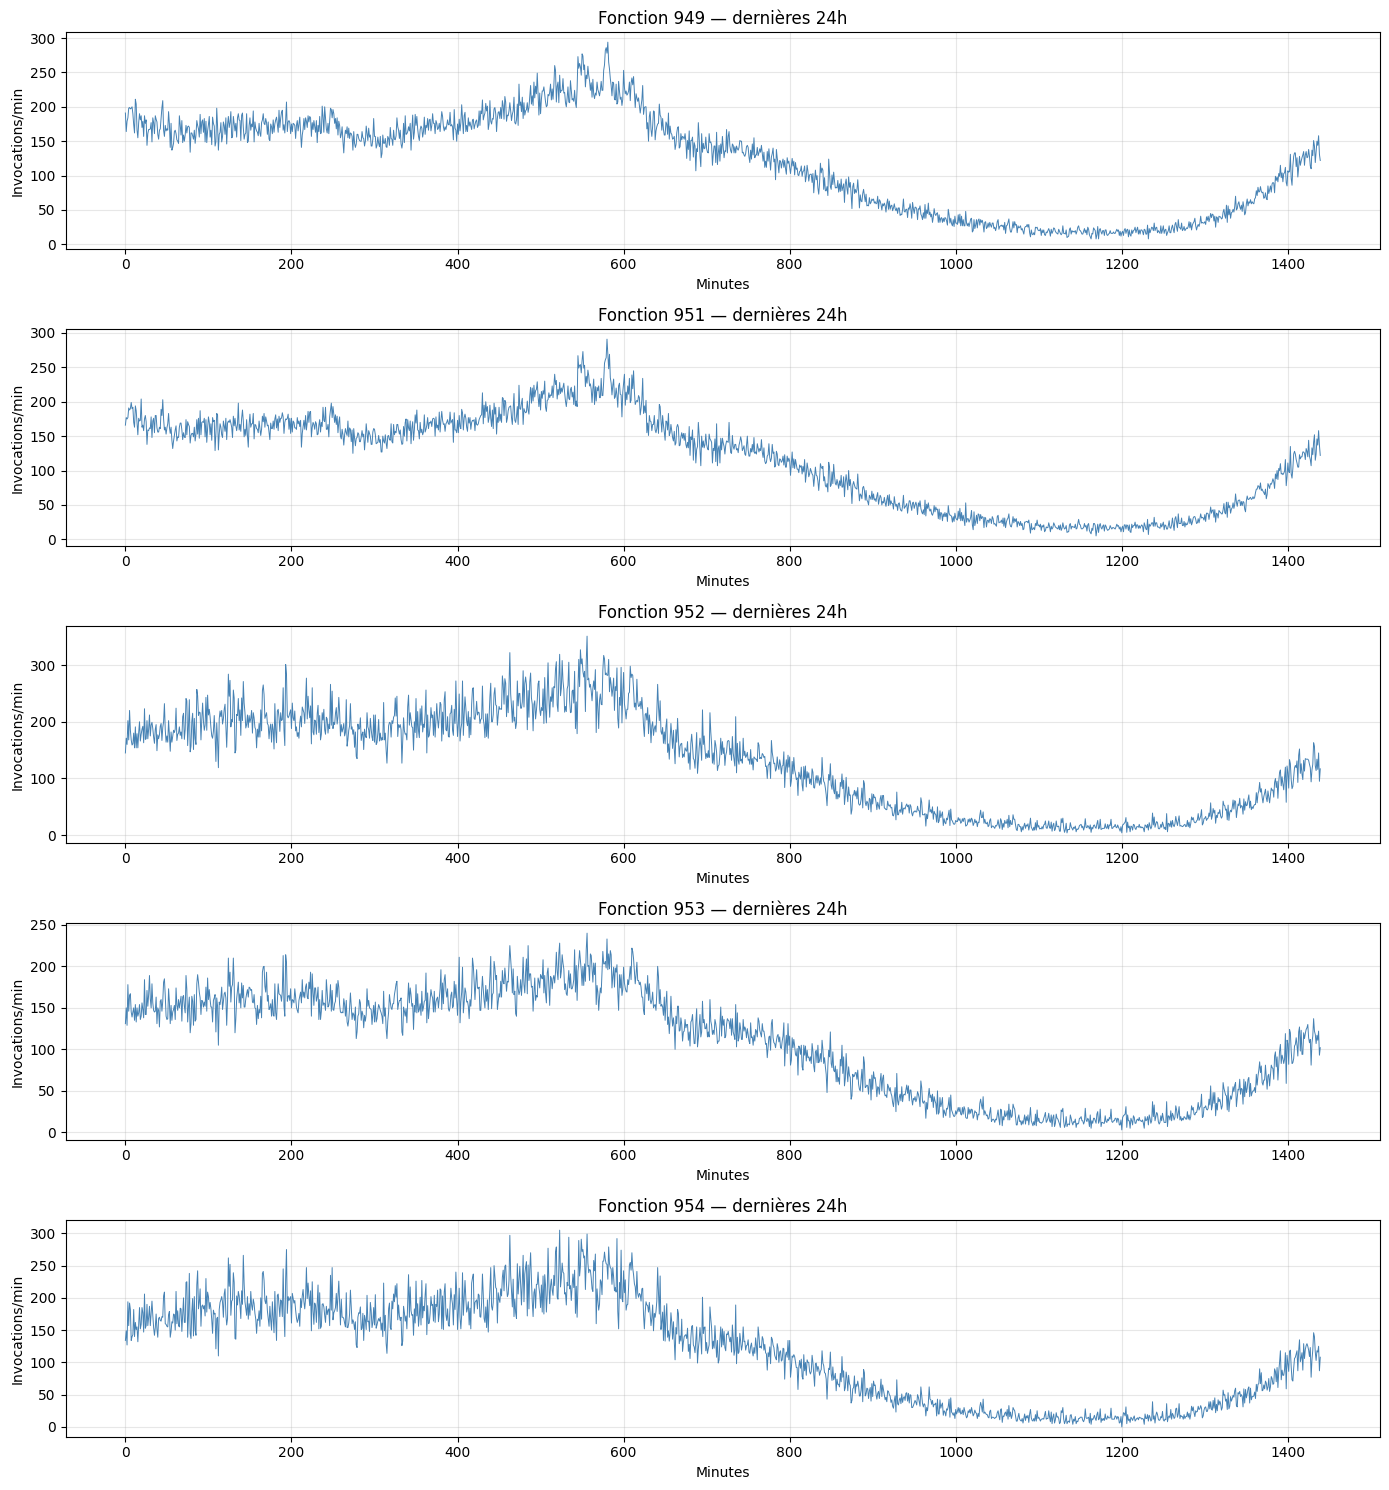

In [7]:
fig, axes = plt.subplots(len(all_series), 1, figsize=(14, 3 * len(all_series)), squeeze=False)
for i, (s, ax) in enumerate(zip(all_series, axes.flatten())):
    ax.plot(s['target_full'][-1440:], lw=0.7, color='steelblue')
    ax.set_title(f"Fonction {s['function_id']} — dernières 24h")
    ax.set_xlabel('Minutes'); ax.set_ylabel('Invocations/min')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5 — Pipeline GluonTS (paramétré par config)

In [8]:
from gluonts.time_feature import get_lags_for_frequency, time_features_from_frequency_str
from gluonts.dataset.field_names import FieldName
from gluonts.transform import (
    AddAgeFeature, AddObservedValuesIndicator, AddTimeFeatures,
    AsNumpyArray, Chain, ExpectedNumInstanceSampler, InstanceSplitter,
    RemoveFields, TestSplitSampler, ValidationSplitSampler,
    VstackFeatures, RenameFields,
)
from gluonts.itertools import Cyclic, Cached
from gluonts.dataset.loader import as_stacked_batches

lags_sequence = get_lags_for_frequency(FREQ)
time_features = time_features_from_frequency_str(FREQ)

@lru_cache(10_000)
def convert_to_pandas_period(date, freq):
    return pd.Period(date, freq)

def transform_start_field(batch, freq):
    batch['start'] = [convert_to_pandas_period(d, freq) for d in batch['start']]
    return batch

for ds in (hpo_train_dataset, hpo_val_dataset, train_dataset, test_dataset):
    ds.set_transform(partial(transform_start_field, freq=FREQ))

print(f'Lags : {len(lags_sequence)} | Time features : {len(time_features)}')

Lags : 22 | Time features : 5


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/lag.py:104: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


In [9]:
def create_transformation(freq, config):
    remove_field_names = []
    if config.num_static_real_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_REAL)
    if config.num_dynamic_real_features == 0:
        remove_field_names.append(FieldName.FEAT_DYNAMIC_REAL)
    if config.num_static_categorical_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_CAT)
    return Chain(
        [RemoveFields(field_names=remove_field_names)]
        + ([AsNumpyArray(field=FieldName.FEAT_STATIC_CAT, expected_ndim=1, dtype=int)]
           if config.num_static_categorical_features > 0 else [])
        + [AsNumpyArray(field=FieldName.TARGET, expected_ndim=1),
           AddObservedValuesIndicator(target_field=FieldName.TARGET,
                                     output_field=FieldName.OBSERVED_VALUES),
           AddTimeFeatures(start_field=FieldName.START, target_field=FieldName.TARGET,
                           output_field=FieldName.FEAT_TIME,
                           time_features=time_features_from_frequency_str(freq),
                           pred_length=config.prediction_length),
           AddAgeFeature(target_field=FieldName.TARGET, output_field=FieldName.FEAT_AGE,
                         pred_length=config.prediction_length, log_scale=True),
           VstackFeatures(output_field=FieldName.FEAT_TIME,
                          input_fields=[FieldName.FEAT_TIME, FieldName.FEAT_AGE]),
           RenameFields(mapping={
               FieldName.FEAT_STATIC_CAT: 'static_categorical_features',
               FieldName.FEAT_TIME:       'time_features',
               FieldName.TARGET:          'values',
               FieldName.OBSERVED_VALUES: 'observed_mask',
           })]
    )

def create_instance_splitter(config, mode):
    sampler = {
        'train':      ExpectedNumInstanceSampler(num_instances=1.0,
                                                 min_future=config.prediction_length),
        'validation': ValidationSplitSampler(min_future=config.prediction_length),
        'test':       TestSplitSampler(),
    }[mode]
    return InstanceSplitter(
        target_field='values', is_pad_field=FieldName.IS_PAD,
        start_field=FieldName.START, forecast_start_field=FieldName.FORECAST_START,
        instance_sampler=sampler,
        past_length=config.context_length + max(config.lags_sequence),
        future_length=config.prediction_length,
        time_series_fields=['time_features', 'observed_mask'],
    )

def _pred_fields(config):
    f = ['past_time_features', 'past_values', 'past_observed_mask', 'future_time_features']
    if config.num_static_categorical_features > 0:
        f.append('static_categorical_features')
    return f

def create_train_dataloader(config, freq, data, batch_size, num_batches_per_epoch):
    fields = _pred_fields(config) + ['future_values', 'future_observed_mask']
    tr = create_transformation(freq, config)
    td = Cached(tr.apply(data, is_train=True))
    sp = create_instance_splitter(config, 'train')
    return as_stacked_batches(sp.apply(Cyclic(td).stream()),
                              batch_size=batch_size, field_names=fields,
                              output_type=torch.tensor,
                              num_batches_per_epoch=num_batches_per_epoch)

def create_backtest_dataloader(config, freq, data, batch_size):
    tr = create_transformation(freq, config)
    sp = create_instance_splitter(config, 'validation')
    return as_stacked_batches(sp.apply(tr.apply(data), is_train=True),
                              batch_size=batch_size, output_type=torch.tensor,
                              field_names=_pred_fields(config))

def create_attention_dataloader(config, freq, data, batch_size=1):
    fields = _pred_fields(config) + ['future_values', 'future_observed_mask']
    tr = create_transformation(freq, config)
    sp = create_instance_splitter(config, 'validation')
    return as_stacked_batches(sp.apply(tr.apply(data), is_train=True),
                              batch_size=batch_size, output_type=torch.tensor,
                              field_names=fields)

print('Pipeline GluonTS prêt.')

Pipeline GluonTS prêt.


## 6 — HPO (Optuna TPE + MedianPruner)

**Stratégie** :
- **Sampler** TPE (Tree-structured Parzen) — bien plus efficace que random search
- **Pruner** Median (élague les trials sous la médiane après 5 epochs de warm-up)
- **Objectif** : moyenne R² sur les 5 fonctions, sur la val (positions -240 à -120)
- **Budget** : 15 trials × 20 epochs, avec pruning agressif → ~1-2h sur T4
- **Storage SQLite sur Drive** : si Colab disconnect, on relance et on reprend


In [10]:
from sklearn.metrics import r2_score

@torch.no_grad()
def evaluate_mean_r2(model, dataloader, dataset, config, device):
    """Mean R² across all series of the dataset."""
    model.eval()
    forecasts = []
    for b in dataloader:
        out = model.generate(
            static_categorical_features=b['static_categorical_features'].to(device)
                if config.num_static_categorical_features > 0 else None,
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
        )
        forecasts.append(out.sequences.cpu().numpy())
    forecasts = np.vstack(forecasts)
    forecast_median = np.median(forecasts, axis=1)
    r2_scores = []
    for ts_idx in range(len(dataset)):
        target = np.array(dataset[ts_idx]['target'])
        actual = target[-config.prediction_length:]
        pred = forecast_median[ts_idx]
        r2_scores.append(r2_score(actual, pred))
    return float(np.mean(r2_scores)), r2_scores

print('Helper évaluation R² prêt.')

Helper évaluation R² prêt.


In [11]:
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction
from torch.optim import AdamW

def build_config(d_model, context_length, encoder_layers, decoder_layers=None, n_series=None):
    if decoder_layers is None:
        decoder_layers = encoder_layers
    if n_series is None:
        n_series = len(train_dataset)
    return TimeSeriesTransformerConfig(
        prediction_length=PREDICTION_LENGTH,
        context_length=context_length,
        lags_sequence=lags_sequence,
        num_time_features=len(time_features) + 1,
        num_static_categorical_features=1,
        cardinality=[n_series],
        embedding_dimension=EMBEDDING_DIM,
        encoder_layers=encoder_layers,
        decoder_layers=decoder_layers,
        d_model=d_model,
        encoder_attention_heads=N_HEADS,
        decoder_attention_heads=N_HEADS,
        encoder_ffn_dim=max(d_model, 32),
        decoder_ffn_dim=max(d_model, 32),
        dropout=DROPOUT,
    )

def objective(trial):
    d_model        = trial.suggest_categorical('d_model', [32, 64, 128])
    context_length = trial.suggest_categorical('context_length', [240, 480, 1440])
    encoder_layers = trial.suggest_int('encoder_layers', 2, 4)
    lr             = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

    print(f'\nTrial {trial.number}: d_model={d_model}, context_length={context_length}, '
          f'encoder_layers={encoder_layers}, lr={lr:.2e}')

    cfg = build_config(d_model, context_length, encoder_layers)

    try:
        model = TimeSeriesTransformerForPrediction(cfg).to(device)
        train_loader = create_train_dataloader(cfg, FREQ, hpo_train_dataset,
                                               BATCH_SIZE_TRAIN, HPO_NUM_BATCHES_EPOCH)
        val_loader   = create_backtest_dataloader(cfg, FREQ, hpo_val_dataset, BATCH_SIZE_TEST)
        optimizer = AdamW(model.parameters(), lr=lr, betas=BETAS, weight_decay=WEIGHT_DECAY)

        best_r2 = -float('inf')
        for epoch in range(HPO_EPOCHS):
            model.train()
            epoch_losses = []
            for b in train_loader:
                optimizer.zero_grad()
                out = model(
                    static_categorical_features=b['static_categorical_features'].to(device),
                    past_time_features=b['past_time_features'].to(device),
                    past_values=b['past_values'].to(device),
                    future_time_features=b['future_time_features'].to(device),
                    future_values=b['future_values'].to(device),
                    past_observed_mask=b['past_observed_mask'].to(device),
                    future_observed_mask=b['future_observed_mask'].to(device),
                )
                out.loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
                epoch_losses.append(out.loss.item())

            if (epoch + 1) % HPO_EVAL_EVERY == 0:
                val_r2, _ = evaluate_mean_r2(model, val_loader, hpo_val_dataset, cfg, device)
                best_r2 = max(best_r2, val_r2)
                print(f'  epoch {epoch:02d}  loss={np.mean(epoch_losses):.4f}  val_r2={val_r2:.4f}')
                trial.report(val_r2, epoch)
                if trial.should_prune():
                    print(f'  → pruned @ epoch {epoch}')
                    del model, optimizer, train_loader, val_loader
                    torch.cuda.empty_cache(); gc.collect()
                    raise optuna.TrialPruned()

        del model, optimizer, train_loader, val_loader
        torch.cuda.empty_cache(); gc.collect()
        return best_r2

    except torch.cuda.OutOfMemoryError:
        print('  → OOM, pruning trial')
        torch.cuda.empty_cache(); gc.collect()
        raise optuna.TrialPruned()

print('Objectif Optuna prêt.')

Objectif Optuna prêt.


In [12]:
study_path = f'{DRIVE_BASE}/hpo/study.db'
study = optuna.create_study(
    study_name='c4-hpo',
    storage=f'sqlite:///{study_path}',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=5),
    load_if_exists=True,
    direction='maximize',
)

n_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Trials déjà complétés (resume) : {n_done}')
print(f'Lancement (target : {HPO_N_TRIALS} trials)...\n')

study.optimize(objective, n_trials=HPO_N_TRIALS, show_progress_bar=False)

print('\n' + '=' * 60)
print(f'HPO terminée — {len(study.trials)} trials, best val R² = {study.best_value:.4f}')
print(f'Best params : {study.best_params}')

with open(f'{DRIVE_BASE}/hpo/best_params.json', 'w') as f:
    json.dump({
        'best_value': study.best_value,
        'best_params': study.best_params,
        'n_trials': len(study.trials),
        'n_completed': len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
        'n_pruned':    len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]),
    }, f, indent=2)

[I 2026-05-14 15:44:11,019] A new study created in RDB with name: c4-hpo


Trials déjà complétés (resume) : 0
Lancement (target : 15 trials)...


Trial 0: d_model=32, context_length=1440, encoder_layers=4, lr=2.72e-04


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/tmp/ipykernel_1388/2811288863.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return pd.Period(date, freq)


  → OOM, pruning trial


[I 2026-05-14 15:44:13,056] Trial 0 pruned. 


...


Trial 14: d_model=128, context_length=240, encoder_layers=4, lr=2.09e-05


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


  epoch 03  loss=5.6163  val_r2=-1.3484
  epoch 07  loss=4.9617  val_r2=-2.1523
  → pruned @ epoch 7


[I 2026-05-14 16:17:55,016] Trial 14 pruned. 



HPO terminée — 15 trials, best val R² = 0.5347
Best params : {'d_model': 128, 'context_length': 240, 'encoder_layers': 4, 'lr': 0.0006408870592758436}


## 7 — Visualisation des résultats HPO

/tmp/ipykernel_1388/2386471003.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = ovm.plot_optimization_history(study)


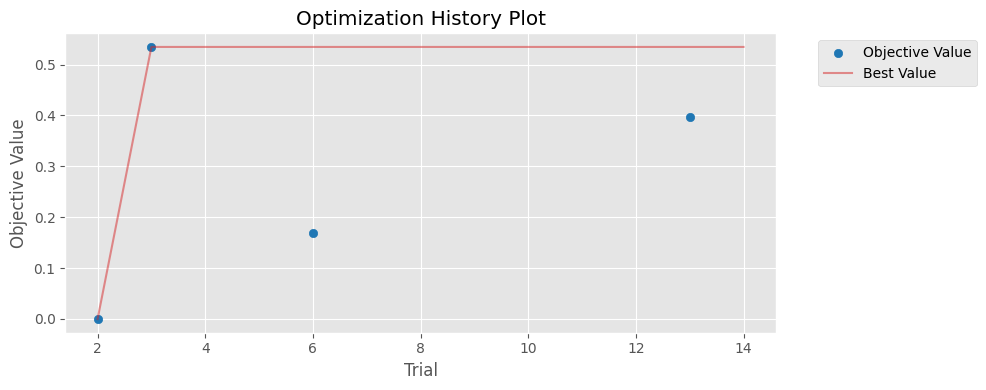

In [13]:
import optuna.visualization.matplotlib as ovm

fig = ovm.plot_optimization_history(study)
plt.gcf().set_size_inches(10, 4); plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/hpo/optimization_history.png', dpi=150); plt.show()

/tmp/ipykernel_1388/1552920787.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = ovm.plot_param_importances(study)


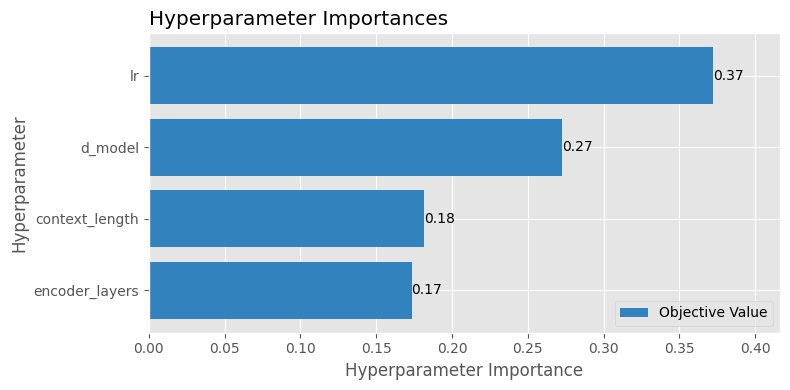

In [14]:
try:
    fig = ovm.plot_param_importances(study)
    plt.gcf().set_size_inches(8, 4); plt.tight_layout()
    plt.savefig(f'{DRIVE_BASE}/hpo/param_importances.png', dpi=150); plt.show()
except (ValueError, RuntimeError) as e:
    print(f'(Importances indisponibles — trop peu de trials complétés : {e})')

/tmp/ipykernel_1388/2156479295.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = ovm.plot_parallel_coordinate(study)


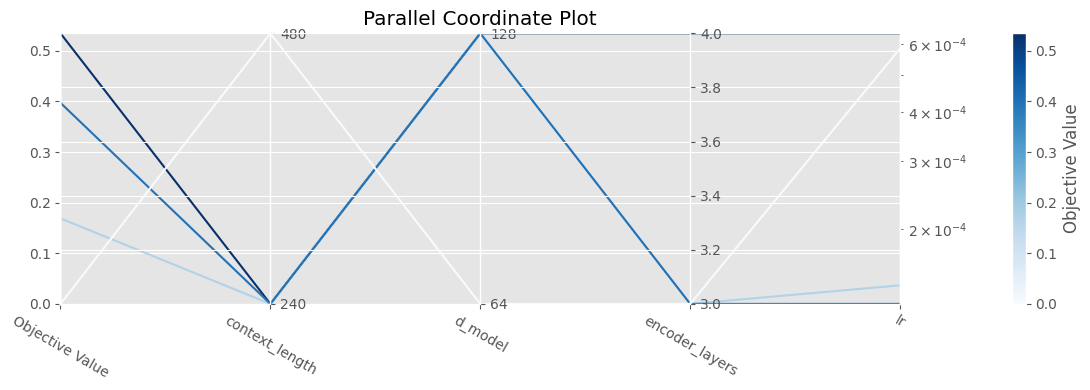

In [15]:
fig = ovm.plot_parallel_coordinate(study)
plt.gcf().set_size_inches(12, 4); plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/hpo/parallel_coordinate.png', dpi=150); plt.show()

In [16]:
print('=' * 60)
print('Best hyperparameters found:')
print('=' * 60)
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f'  {k:<20s} = {v:.2e}')
    else:
        print(f'  {k:<20s} = {v}')
print(f'\n  Best val R²       = {study.best_value:.4f}')
print(f'  Baseline FAYAM R² = 0.3701 (référence)')
print(f'  Improvement       = {(study.best_value - 0.3701) * 100:+.2f} pp')

trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params'))
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].sort_values('value', ascending=False).head(5)
print('\n── Top 5 trials ──')
print(trials_df.to_string(index=False))

Best hyperparameters found:
  d_model              = 128
  context_length       = 240
  encoder_layers       = 4
  lr                   = 6.41e-04

  Best val R²       = 0.5347
  Baseline FAYAM R² = 0.3701 (référence)
  Improvement       = +16.46 pp

── Top 5 trials ──
 number     value    state  params_context_length  params_d_model  params_encoder_layers  params_lr
      3  0.534692 COMPLETE                    240             128                      4   0.000641
     13  0.397186 COMPLETE                    240             128                      3   0.000128
      6  0.168709 COMPLETE                    240             128                      3   0.000143
      2 -0.000421 COMPLETE                    480              64                      3   0.000586


## 8 — Entraînement final avec early stopping

- Hyperparams = `study.best_params`
- Train sur `train_dataset` (= train baseline FAYAM)
- Validation sur `hpo_val_dataset` pour early stopping
- Patience = 10 epochs, max = 80 epochs
- Sauvegarde du meilleur état (val R² max)


In [17]:
best_d_model = study.best_params['d_model']
best_ctx     = study.best_params['context_length']
best_layers  = study.best_params['encoder_layers']
best_lr      = study.best_params['lr']

cfg_opt = build_config(best_d_model, best_ctx, best_layers)
model_opt = TimeSeriesTransformerForPrediction(cfg_opt).to(device)

n_params = sum(p.numel() for p in model_opt.parameters())
print('Modèle optimisé construit :')
print(f'  d_model        = {best_d_model}')
print(f'  context_length = {best_ctx}')
print(f'  encoder_layers = {best_layers}')
print(f'  decoder_layers = {best_layers}')
print(f'  lr             = {best_lr:.2e}')
print(f'  paramètres     = {n_params:,}')

Modèle optimisé construit :
  d_model        = 128
  context_length = 240
  encoder_layers = 4
  decoder_layers = 4
  lr             = 6.41e-04
  paramètres     = 1,163,149


In [18]:
train_loader_opt = create_train_dataloader(cfg_opt, FREQ, train_dataset,
                                           BATCH_SIZE_TRAIN, NUM_BATCHES_EPOCH)
val_loader_opt   = create_backtest_dataloader(cfg_opt, FREQ, hpo_val_dataset, BATCH_SIZE_TEST)

optimizer_opt = AdamW(model_opt.parameters(), lr=best_lr, betas=BETAS, weight_decay=WEIGHT_DECAY)

loss_history, val_r2_history = [], []
best_val_r2 = -float('inf')
patience_counter = 0
best_state = None
ckpt_path = f'{DRIVE_BASE}/checkpoints/model_optimized_final.pt'

for epoch in range(FINAL_MAX_EPOCHS):
    model_opt.train()
    epoch_losses = []
    pbar = tqdm(train_loader_opt, desc=f'Epoch {epoch:03d}', leave=False)
    for b in pbar:
        optimizer_opt.zero_grad()
        out = model_opt(
            static_categorical_features=b['static_categorical_features'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            future_values=b['future_values'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_observed_mask=b['future_observed_mask'].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model_opt.parameters(), GRAD_CLIP_NORM)
        optimizer_opt.step()
        epoch_losses.append(out.loss.item())
        pbar.set_postfix({'loss': f'{out.loss.item():.4f}'})

    mean_loss = float(np.mean(epoch_losses))
    loss_history.append({'epoch': epoch, 'loss': mean_loss})

    val_r2, _ = evaluate_mean_r2(model_opt, val_loader_opt, hpo_val_dataset, cfg_opt, device)
    val_r2_history.append({'epoch': epoch, 'val_r2': val_r2})

    line = f'Epoch {epoch:03d}  loss={mean_loss:.4f}  val_r2={val_r2:.4f}'
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model_opt.state_dict().items()}
        torch.save({'epoch': epoch, 'model': best_state, 'val_r2': val_r2,
                    'loss_history': loss_history, 'val_r2_history': val_r2_history,
                    'hyperparameters': study.best_params}, ckpt_path)
        print(line + '  ← best (saved)')
    else:
        patience_counter += 1
        print(line + f'  (patience {patience_counter}/{FINAL_PATIENCE})')
        if patience_counter >= FINAL_PATIENCE:
            print(f'\nEarly stopping @ epoch {epoch} (best val_r2={best_val_r2:.4f})')
            break

if best_state is not None:
    model_opt.load_state_dict(best_state)
print(f'\nEntraînement final terminé — best val_r2 = {best_val_r2:.4f}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Epoch 000: 0it [00:00, ?it/s]

Epoch 000  loss=4.8893  val_r2=-1.4463  ← best (saved)


Epoch 001: 0it [00:00, ?it/s]

Epoch 001  loss=4.5381  val_r2=-0.5156  ← best (saved)


...

Epoch 011  loss=4.1071  val_r2=-2.3345  (patience 8/10)


Epoch 012: 0it [00:00, ?it/s]

Epoch 012  loss=4.1439  val_r2=-5.1296  (patience 9/10)


Epoch 013: 0it [00:00, ?it/s]

Epoch 013  loss=4.1189  val_r2=-1.3209  (patience 10/10)

Early stopping @ epoch 13 (best val_r2=0.4839)

Entraînement final terminé — best val_r2 = 0.4839


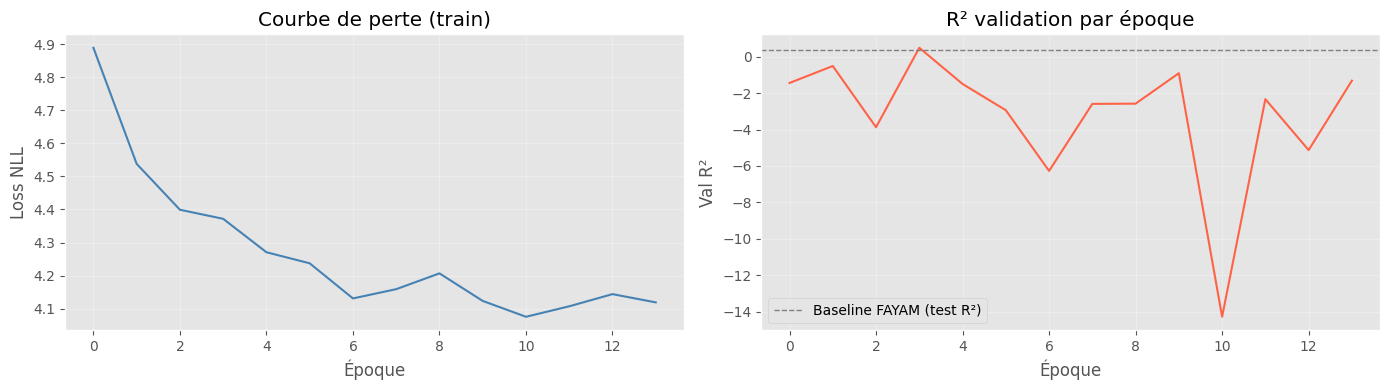

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot([x['epoch'] for x in loss_history], [x['loss'] for x in loss_history],
             lw=1.5, color='steelblue')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss NLL')
axes[0].set_title('Courbe de perte (train)'); axes[0].grid(alpha=0.3)

axes[1].plot([x['epoch'] for x in val_r2_history], [x['val_r2'] for x in val_r2_history],
             lw=1.5, color='tomato')
axes[1].axhline(0.3701, color='gray', lw=1, ls='--', label='Baseline FAYAM (test R²)')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Val R²')
axes[1].set_title('R² validation par époque'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/training_curves.png', dpi=150); plt.show()

## 9 — Inférence et métriques sur test

In [20]:
test_loader_opt = create_backtest_dataloader(cfg_opt, FREQ, test_dataset, BATCH_SIZE_TEST)
model_opt.eval()
forecasts_opt = []
with torch.no_grad():
    for b in tqdm(test_loader_opt, desc='Inférence test'):
        out = model_opt.generate(
            static_categorical_features=b['static_categorical_features'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
        )
        forecasts_opt.append(out.sequences.cpu().numpy())
forecasts_opt = np.vstack(forecasts_opt)
print(f'Shape forecasts : {forecasts_opt.shape}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Inférence test: 0it [00:00, ?it/s]

Shape forecasts : (5, 100, 120)


In [21]:
from evaluate import load as load_metric
from gluonts.time_feature import get_seasonality
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

mase_metric  = load_metric('evaluate-metric/mase')
smape_metric = load_metric('evaluate-metric/smape')
forecast_median_opt = np.median(forecasts_opt, axis=1)

all_metrics_opt = []
for ts_idx in range(len(test_dataset)):
    pred   = forecast_median_opt[ts_idx]
    actual = np.array(test_dataset[ts_idx]['target'][-PREDICTION_LENGTH:])
    train_ = np.array(test_dataset[ts_idx]['target'][:-PREDICTION_LENGTH])

    mase  = mase_metric.compute(predictions=pred, references=actual,
                                 training=train_,
                                 periodicity=get_seasonality(FREQ))['mase']
    smape = smape_metric.compute(predictions=pred, references=actual)['smape']
    rmse  = float(np.sqrt(mean_squared_error(actual, pred)))
    r2    = float(r2_score(actual, pred))
    sp    = float(spearmanr(actual, pred).statistic)

    all_metrics_opt.append({
        'ts_index':    ts_idx,
        'function_id': test_dataset[ts_idx]['function_id'],
        'MASE':  mase, 'sMAPE': smape, 'RMSE': rmse,
        'R2':    r2,   'Spearman': sp,
    })

df_metrics_opt = pd.DataFrame(all_metrics_opt)
print('── Métriques optimisé par fonction ──')
print(df_metrics_opt[['function_id', 'MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']].to_string(index=False))
print('\n── Moyennes ──')
print(df_metrics_opt[['MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']].mean().round(4))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


── Métriques optimisé par fonction ──
 function_id     MASE    sMAPE      RMSE        R2  Spearman
         949 2.816684 0.519113 48.310988 -1.256465  0.922600
         951 2.843725 0.523222 47.297213 -1.233405  0.917759
         952 1.994794 0.599643 51.922676 -1.441813  0.802992
         953 2.426292 0.562650 45.135909 -1.495361  0.825674
         954 1.988804 0.606324 47.951598 -1.499979  0.797664

── Moyennes ──
MASE         2.4141
sMAPE        0.5622
RMSE        48.1237
R2          -1.3854
Spearman     0.8533
dtype: float64


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


In [22]:
df_metrics_opt.to_csv(f'{DRIVE_BASE}/results/metrics_optimized.csv', index=False)
with open(f'{DRIVE_BASE}/results/metrics_optimized.json', 'w') as f:
    json.dump({
        'run_name': RUN_NAME, 'cluster': CLUSTER_ID, 'seed': SEED,
        'hyperparameters': study.best_params,
        'val_r2_best': best_val_r2,
        'global': df_metrics_opt[['MASE','sMAPE','RMSE','R2','Spearman']].mean().round(4).to_dict(),
        'per_function': df_metrics_opt.to_dict(orient='records'),
    }, f, indent=2)
print('Métriques sauvegardées.')

Métriques sauvegardées.


## 10 — Prévisions par fonction

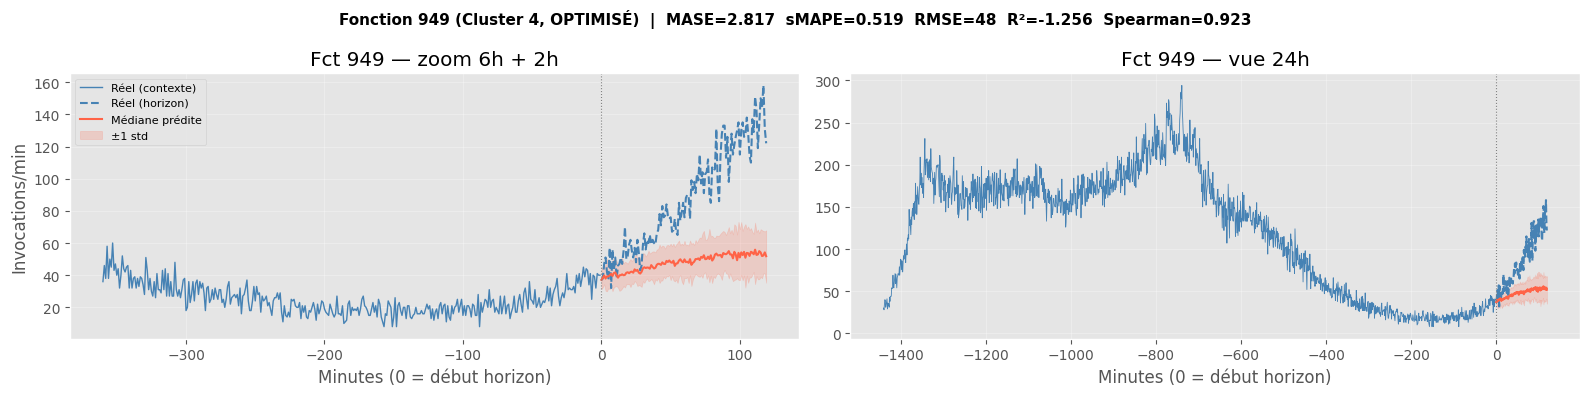

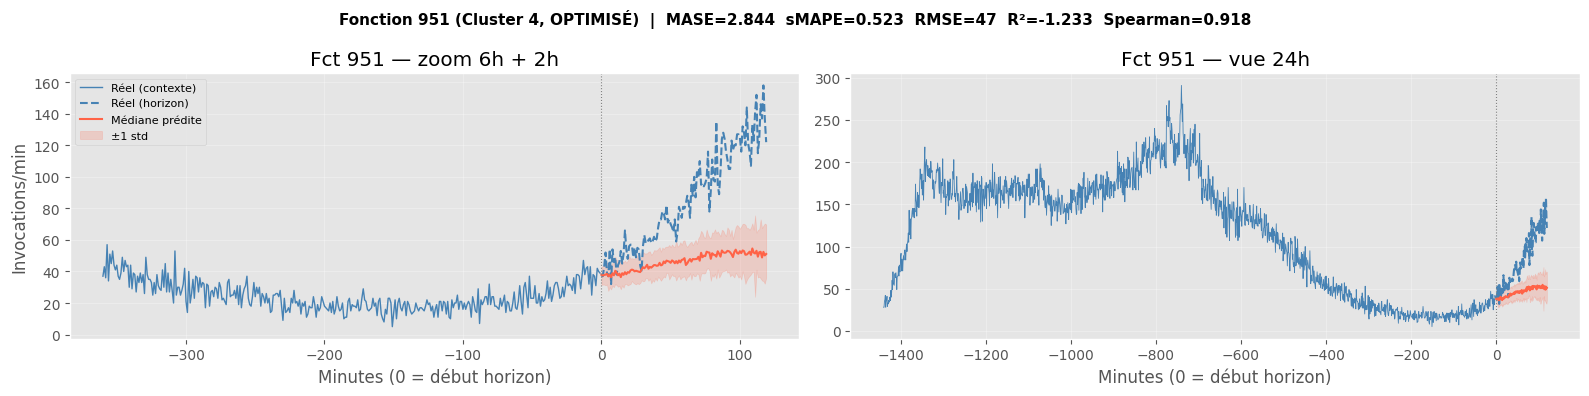

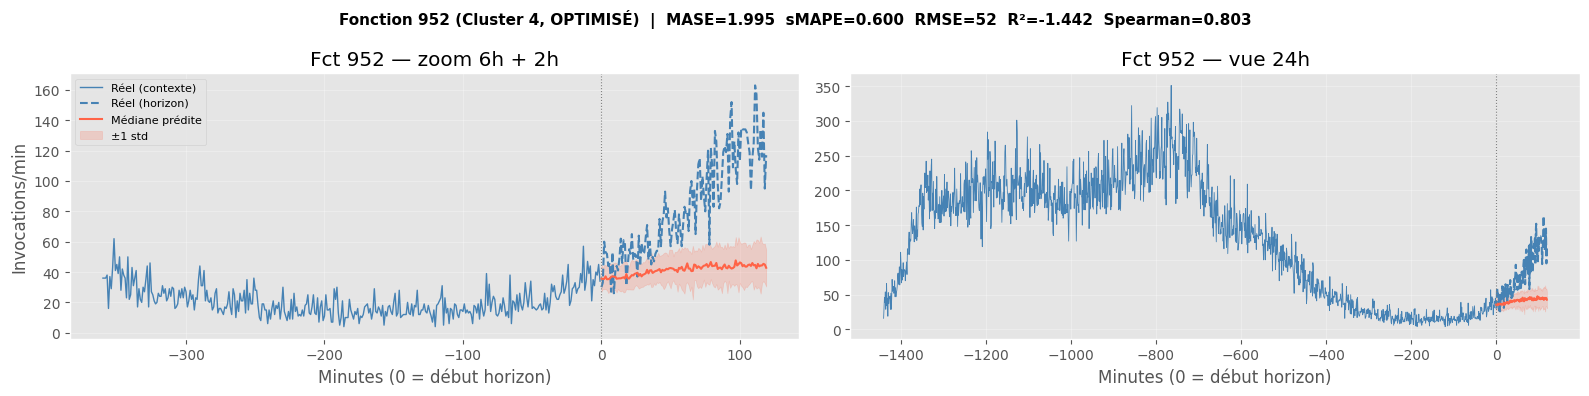

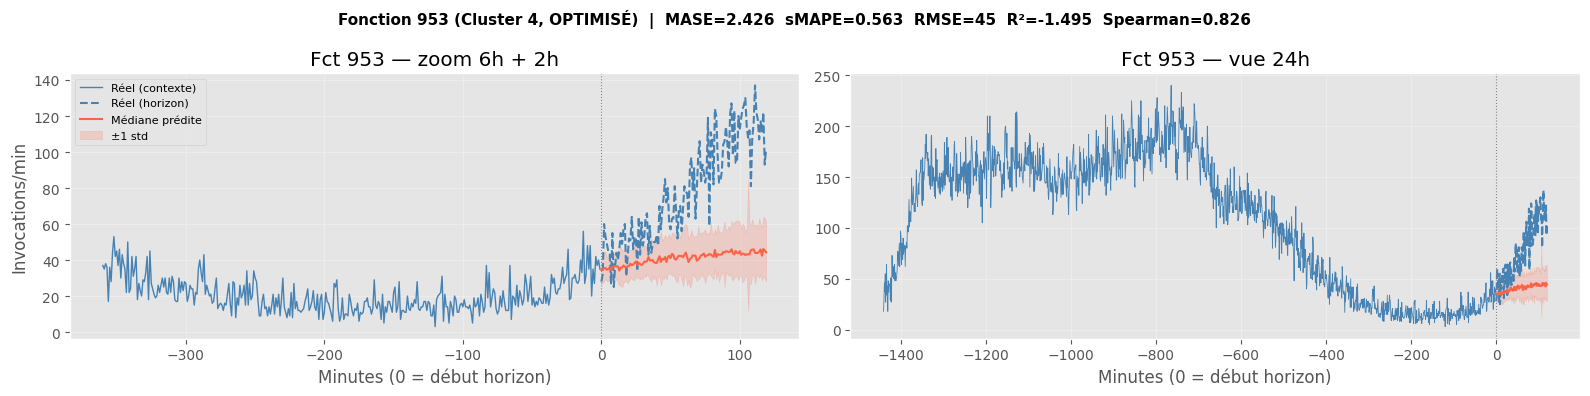

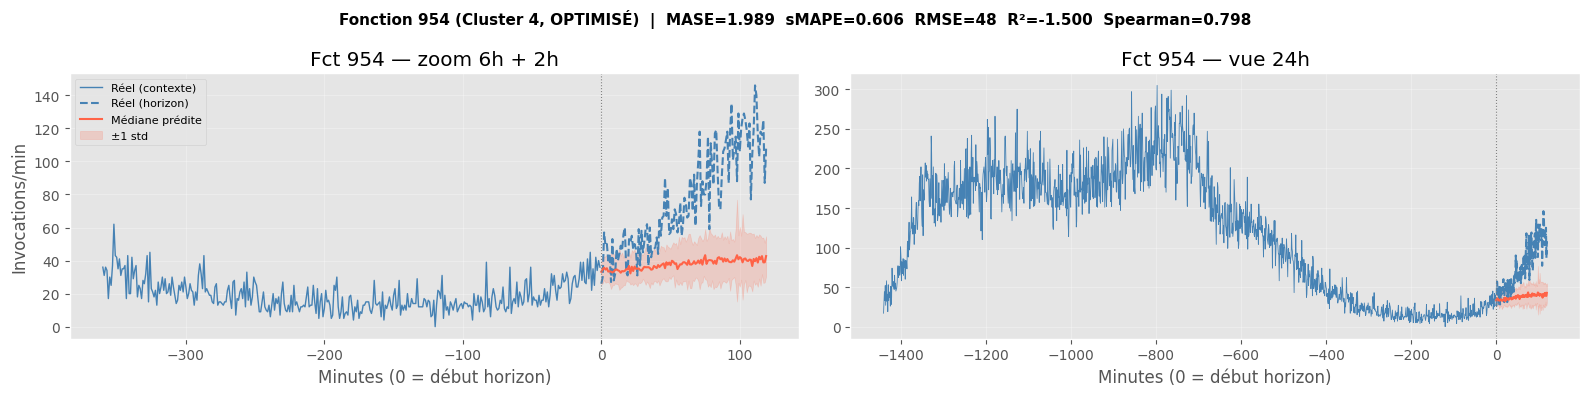

In [23]:
CONTEXT_DISPLAY = 360

for ts_idx, s in enumerate(all_series):
    func_id = s['function_id']
    row     = df_metrics_opt[df_metrics_opt['ts_index'] == ts_idx].iloc[0]

    actual  = np.array(test_dataset[ts_idx]['target'])
    pred_m  = forecast_median_opt[ts_idx]
    pred_lo = forecasts_opt[ts_idx].mean(0) - forecasts_opt[ts_idx].std(0)
    pred_hi = forecasts_opt[ts_idx].mean(0) + forecasts_opt[ts_idx].std(0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    ax = axes[0]
    n_ctx  = CONTEXT_DISPLAY
    x_ctx  = np.arange(-n_ctx, 0)
    x_pred = np.arange(0, PREDICTION_LENGTH)
    ax.plot(x_ctx,  actual[-(n_ctx + PREDICTION_LENGTH):-PREDICTION_LENGTH],
            color='steelblue', lw=1, label='Réel (contexte)')
    ax.plot(x_pred, actual[-PREDICTION_LENGTH:],
            color='steelblue', lw=1.5, ls='--', label='Réel (horizon)')
    ax.plot(x_pred, pred_m,  color='tomato', lw=1.5, label='Médiane prédite')
    ax.fill_between(x_pred, pred_lo, pred_hi, color='tomato', alpha=0.2, label='±1 std')
    ax.axvline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('Minutes (0 = début horizon)'); ax.set_ylabel('Invocations/min')
    ax.set_title(f'Fct {func_id} — zoom 6h + 2h'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax2 = axes[1]
    n_day = 1440
    x_day  = np.arange(-n_day, 0)
    ax2.plot(x_day, actual[-(n_day + PREDICTION_LENGTH):-PREDICTION_LENGTH],
             color='steelblue', lw=0.6, label='Réel (24h)')
    ax2.plot(x_pred, actual[-PREDICTION_LENGTH:],
             color='steelblue', lw=1.5, ls='--')
    ax2.plot(x_pred, pred_m, color='tomato', lw=1.5)
    ax2.fill_between(x_pred, pred_lo, pred_hi, color='tomato', alpha=0.2)
    ax2.axvline(0, color='gray', lw=0.8, ls=':')
    ax2.set_xlabel('Minutes (0 = début horizon)')
    ax2.set_title(f'Fct {func_id} — vue 24h'); ax2.grid(alpha=0.3)

    fig.suptitle(
        f'Fonction {func_id} (Cluster {CLUSTER_ID}, OPTIMISÉ)  |  '
        f'MASE={row.MASE:.3f}  sMAPE={row.sMAPE:.3f}  RMSE={row.RMSE:.0f}  '
        f'R²={row.R2:.3f}  Spearman={row.Spearman:.3f}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{DRIVE_BASE}/results/forecast_function_{func_id}.png', dpi=150)
    plt.show()

## 11 — Comparaison vs FAYAM baseline

In [24]:
# Baseline FAYAM (du run baseline-cluster4 du 2026-05-05)
fayam_metrics = pd.DataFrame([
    {'function_id': 949, 'MASE': 1.698746, 'sMAPE': 0.221424, 'RMSE': 29.720628, 'R2': 0.146010, 'Spearman': 0.953155},
    {'function_id': 951, 'MASE': 1.621126, 'sMAPE': 0.212783, 'RMSE': 27.735318, 'R2': 0.231998, 'Spearman': 0.956879},
    {'function_id': 952, 'MASE': 0.973539, 'sMAPE': 0.239281, 'RMSE': 25.098935, 'R2': 0.429430, 'Spearman': 0.903363},
    {'function_id': 953, 'MASE': 0.927301, 'sMAPE': 0.180401, 'RMSE': 17.979290, 'R2': 0.604056, 'Spearman': 0.897334},
    {'function_id': 954, 'MASE': 0.927908, 'sMAPE': 0.233136, 'RMSE': 22.719225, 'R2': 0.438801, 'Spearman': 0.886872},
])

cmp = fayam_metrics.merge(df_metrics_opt, on='function_id', suffixes=('_fayam', '_opt'))

print('=' * 90)
print('Comparaison FAYAM baseline vs Optimisé — Cluster 4')
print('=' * 90)
for _, row in cmp.iterrows():
    print(f'\nFonction {int(row.function_id)}:')
    for metric in ['MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']:
        f = row[f'{metric}_fayam']; o = row[f'{metric}_opt']; diff = o - f
        better = '↑' if (metric in ['R2', 'Spearman'] and diff > 0) or (metric in ['MASE', 'sMAPE', 'RMSE'] and diff < 0) else '↓'
        print(f'  {metric:<10s}  FAYAM={f:.4f}   Opt={o:.4f}   Δ={diff:+.4f}  {better}')

print('\n' + '=' * 90)
print('Moyennes :')
print('=' * 90)
for metric in ['MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']:
    f = cmp[f'{metric}_fayam'].mean(); o = cmp[f'{metric}_opt'].mean()
    print(f'  {metric:<10s}  FAYAM={f:.4f}   Opt={o:.4f}   Δ={o-f:+.4f}')

cmp.to_csv(f'{DRIVE_BASE}/results/comparison_fayam_vs_optimized.csv', index=False)

Comparaison FAYAM baseline vs Optimisé — Cluster 4

Fonction 949:
  MASE        FAYAM=1.6987   Opt=2.8167   Δ=+1.1179  ↓
  sMAPE       FAYAM=0.2214   Opt=0.5191   Δ=+0.2977  ↓
  RMSE        FAYAM=29.7206   Opt=48.3110   Δ=+18.5904  ↓
  R2          FAYAM=0.1460   Opt=-1.2565   Δ=-1.4025  ↓
  Spearman    FAYAM=0.9532   Opt=0.9226   Δ=-0.0306  ↓

Fonction 951:
  MASE        FAYAM=1.6211   Opt=2.8437   Δ=+1.2226  ↓
  sMAPE       FAYAM=0.2128   Opt=0.5232   Δ=+0.3104  ↓
  RMSE        FAYAM=27.7353   Opt=47.2972   Δ=+19.5619  ↓
  R2          FAYAM=0.2320   Opt=-1.2334   Δ=-1.4654  ↓
  Spearman    FAYAM=0.9569   Opt=0.9178   Δ=-0.0391  ↓

Fonction 952:
  MASE        FAYAM=0.9735   Opt=1.9948   Δ=+1.0213  ↓
  sMAPE       FAYAM=0.2393   Opt=0.5996   Δ=+0.3604  ↓
  RMSE        FAYAM=25.0989   Opt=51.9227   Δ=+26.8237  ↓
  R2          FAYAM=0.4294   Opt=-1.4418   Δ=-1.8712  ↓
  Spearman    FAYAM=0.9034   Opt=0.8030   Δ=-0.1004  ↓

Fonction 953:
  MASE        FAYAM=0.9273   Opt=2.4263   Δ=+1.4990 

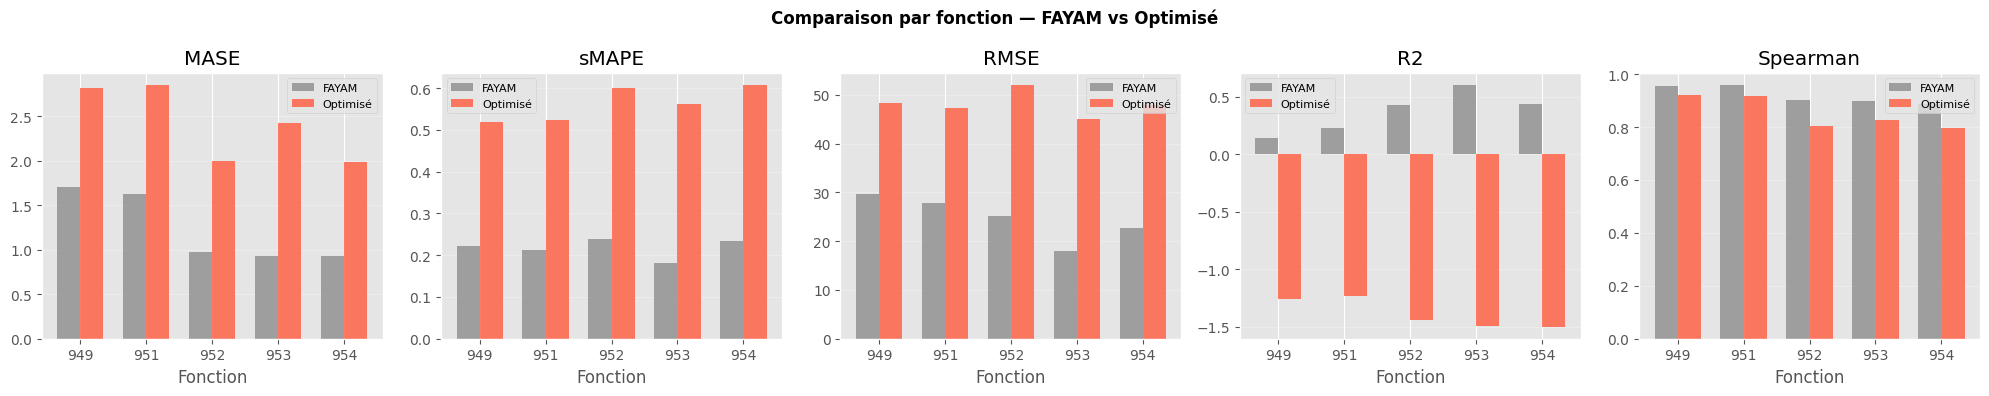

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, m in enumerate(['MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']):
    x = np.arange(len(cmp)); w = 0.35
    axes[i].bar(x - w/2, cmp[f'{m}_fayam'], w, label='FAYAM', color='gray', alpha=0.7)
    axes[i].bar(x + w/2, cmp[f'{m}_opt'],   w, label='Optimisé', color='tomato', alpha=0.85)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(int(f)) for f in cmp['function_id']])
    axes[i].set_xlabel('Fonction'); axes[i].set_title(m); axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('Comparaison par fonction — FAYAM vs Optimisé', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/comparison_barchart.png', dpi=150); plt.show()

## 12 — Extraction attention (sanity check pour H1)

In [26]:
attn_loader = create_attention_dataloader(cfg_opt, FREQ, test_dataset, batch_size=1)

model_opt.eval()
cross_attn_list, enc_attn_list = [], []

with torch.no_grad():
    for i, batch in enumerate(tqdm(attn_loader, total=len(all_series), desc='Attention')):
        if i >= len(all_series): break
        out = model_opt(
            past_values=batch['past_values'].to(device),
            past_time_features=batch['past_time_features'].to(device),
            past_observed_mask=batch['past_observed_mask'].to(device),
            future_values=batch['future_values'].to(device),
            future_time_features=batch['future_time_features'].to(device),
            future_observed_mask=batch['future_observed_mask'].to(device),
            static_categorical_features=batch['static_categorical_features'].to(device),
            output_attentions=True,
        )
        cross_attn_list.append(out.cross_attentions[-1].squeeze(0).cpu().numpy())
        enc_attn_list.append(out.encoder_attentions[-1].squeeze(0).cpu().numpy())

cross_attn_arr = np.stack(cross_attn_list)
enc_attn_arr   = np.stack(enc_attn_list)

np.save(f'{DRIVE_BASE}/attentions/cross_attentions_last_layer.npy', cross_attn_arr)
np.save(f'{DRIVE_BASE}/attentions/encoder_attentions_last_layer.npy', enc_attn_arr)
print(f'cross_attn_arr : {cross_attn_arr.shape}')
print(f'enc_attn_arr   : {enc_attn_arr.shape}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Attention:   0%|          | 0/5 [00:00<?, ?it/s]

cross_attn_arr : (5, 2, 120, 240)
enc_attn_arr   : (5, 2, 240, 240)


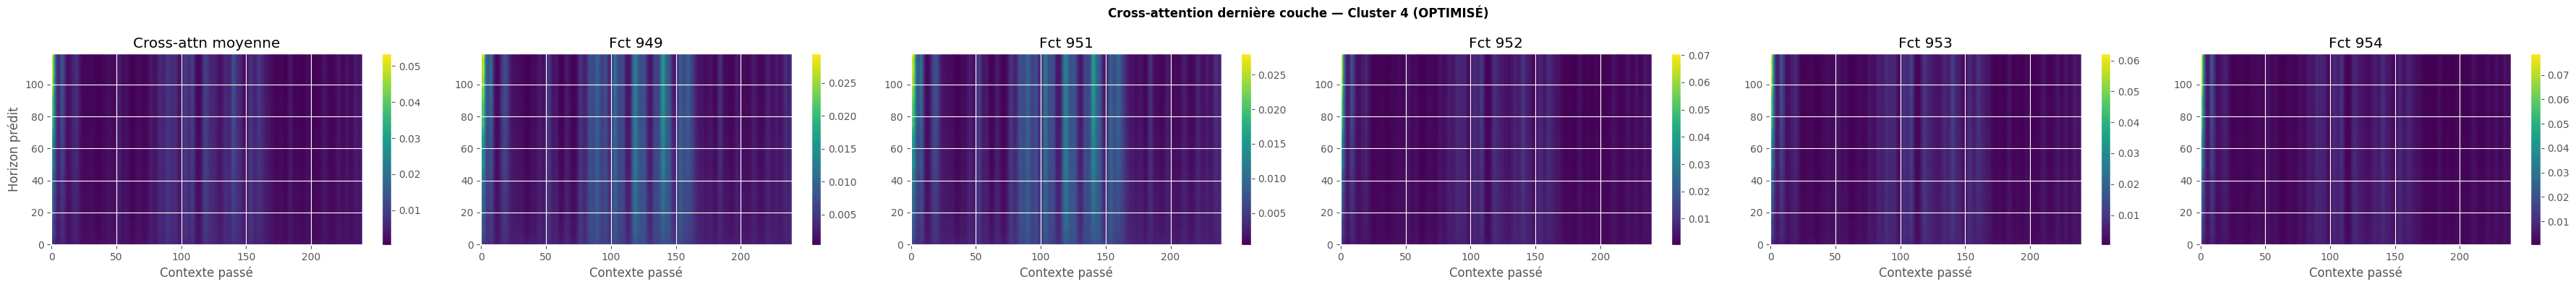

In [27]:
fig, axes = plt.subplots(1, len(all_series) + 1, figsize=(6 * (len(all_series) + 1), 4))

mean_cross = cross_attn_arr.mean(axis=(0, 1))
im = axes[0].imshow(mean_cross, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Cross-attn moyenne')
axes[0].set_xlabel('Contexte passé'); axes[0].set_ylabel('Horizon prédit')

for ts_idx, s in enumerate(all_series):
    mc = cross_attn_arr[ts_idx].mean(axis=0)
    im2 = axes[ts_idx + 1].imshow(mc, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(im2, ax=axes[ts_idx + 1])
    axes[ts_idx + 1].set_title(f'Fct {s["function_id"]}')
    axes[ts_idx + 1].set_xlabel('Contexte passé')

plt.suptitle(f'Cross-attention dernière couche — Cluster {CLUSTER_ID} (OPTIMISÉ)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/attentions/cross_attention_heatmap.png', dpi=150); plt.show()

## 13 — Ablation : modèle dédié sur la fonction 949

Diagnostic per-function. On entraîne un modèle dédié à la 949 avec les hyperparams optimaux trouvés.
Résultat possible :
- R² 949-dédié **>** R² 949-multi → la fonction est *écrasée* par le multi-task
- R² 949-dédié **≈** R² 949-multi → la fonction est *intrinsèquement difficile*
- R² 949-dédié **<** R² 949-multi → le multi-task apporte un *transfert positif*


In [28]:
s_949 = next(s for s in all_series if s['function_id'] == 949)

train_949 = Dataset.from_list([{
    'start': START_DATE, 'feat_static_cat': [0], 'cluster': CLUSTER_ID, 'function_id': 949,
    'target': s_949['target_full'][:-PREDICTION_LENGTH].tolist(),
}])
test_949 = Dataset.from_list([{
    'start': START_DATE, 'feat_static_cat': [0], 'cluster': CLUSTER_ID, 'function_id': 949,
    'target': s_949['target_full'].tolist(),
}])
hpo_val_949 = Dataset.from_list([{
    'start': START_DATE, 'feat_static_cat': [0], 'cluster': CLUSTER_ID, 'function_id': 949,
    'target': s_949['target_full'][:-PREDICTION_LENGTH].tolist(),
}])
for ds in (train_949, test_949, hpo_val_949):
    ds.set_transform(partial(transform_start_field, freq=FREQ))

cfg_949 = build_config(best_d_model, best_ctx, best_layers, n_series=1)
model_949 = TimeSeriesTransformerForPrediction(cfg_949).to(device)
optimizer_949 = AdamW(model_949.parameters(), lr=best_lr, betas=BETAS, weight_decay=WEIGHT_DECAY)

train_loader_949 = create_train_dataloader(cfg_949, FREQ, train_949, BATCH_SIZE_TRAIN, NUM_BATCHES_EPOCH)
val_loader_949   = create_backtest_dataloader(cfg_949, FREQ, hpo_val_949, BATCH_SIZE_TEST)

loss_hist_949, val_hist_949 = [], []
best_val_949 = -float('inf')
patience = 0
best_state_949 = None

print('Entraînement modèle dédié 949...')
for epoch in range(FINAL_MAX_EPOCHS):
    model_949.train()
    losses = []
    for b in train_loader_949:
        optimizer_949.zero_grad()
        out = model_949(
            static_categorical_features=b['static_categorical_features'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            future_values=b['future_values'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_observed_mask=b['future_observed_mask'].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model_949.parameters(), GRAD_CLIP_NORM)
        optimizer_949.step()
        losses.append(out.loss.item())

    val_r2_949, _ = evaluate_mean_r2(model_949, val_loader_949, hpo_val_949, cfg_949, device)
    loss_hist_949.append({'epoch': epoch, 'loss': float(np.mean(losses))})
    val_hist_949.append({'epoch': epoch, 'val_r2': val_r2_949})

    line = f'Epoch {epoch:03d}  loss={np.mean(losses):.4f}  val_r2={val_r2_949:.4f}'
    if val_r2_949 > best_val_949:
        best_val_949 = val_r2_949
        patience = 0
        best_state_949 = {k: v.cpu().clone() for k, v in model_949.state_dict().items()}
        print(line + '  ← best')
    else:
        patience += 1
        print(line + f'  (patience {patience}/{FINAL_PATIENCE})')
        if patience >= FINAL_PATIENCE:
            print(f'Early stop @ epoch {epoch}')
            break

model_949.load_state_dict(best_state_949)
torch.save({'model': best_state_949, 'hyperparameters': study.best_params,
            'val_r2_best': best_val_949},
           f'{DRIVE_BASE}/checkpoints/model_949_dedicated.pt')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Entraînement modèle dédié 949...
Epoch 000  loss=4.9149  val_r2=-5.8371  ← best
Epoch 001  loss=4.3396  val_r2=-8.8663  (patience 1/10)
Epoch 002  loss=4.2599  val_r2=-1.6724  ← best
Epoch 003  loss=4.3243  val_r2=-4.6806  (patience 1/10)
Epoch 004  loss=4.1434  val_r2=-16.1340  (patience 2/10)
Epoch 005  loss=3.9926  val_r2=-0.8690  ← best
Epoch 006  loss=3.9679  val_r2=-7.8594  (patience 1/10)
Epoch 007  loss=4.1109  val_r2=-2.9995  (patience 2/10)
Epoch 008  loss=3.9668  val_r2=0.4032  ← best
Epoch 009  loss=3.9126  val_r2=-6.2536  (patience 1/10)
Epoch 010  loss=3.9411  val_r2=-5.8703  (patience 2/10)
Epoch 011  loss=3.9206  val_r2=0.6371  ← best
Epoch 012  loss=3.8649  val_r2=-3.4233  (patience 1/10)
Epoch 013  loss=3.8952  val_r2=-4.0915  (patience 2/10)
Epoch 014  loss=3.8180  val_r2=0.2355  (patience 3/10)
Epoch 015  loss=3.8956  val_r2=-1.4875  (patience 4/10)
Epoch 016  loss=3.8873  val_r2=-3.6065  (patience 5/10)
Epoch 017  loss=3.8635  val_r2=-2.1473  (patience 6/10)
Epoch 

In [29]:
test_loader_949 = create_backtest_dataloader(cfg_949, FREQ, test_949, BATCH_SIZE_TEST)
model_949.eval()
with torch.no_grad():
    forecasts_949 = []
    for b in test_loader_949:
        out = model_949.generate(
            static_categorical_features=b['static_categorical_features'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
        )
        forecasts_949.append(out.sequences.cpu().numpy())
forecasts_949 = np.vstack(forecasts_949)
pred_949 = np.median(forecasts_949, axis=1)[0]

actual_949 = np.array(test_949[0]['target'][-PREDICTION_LENGTH:])
train_949_vals = np.array(test_949[0]['target'][:-PREDICTION_LENGTH])

mase_949  = mase_metric.compute(predictions=pred_949, references=actual_949,
                                 training=train_949_vals,
                                 periodicity=get_seasonality(FREQ))['mase']
smape_949 = smape_metric.compute(predictions=pred_949, references=actual_949)['smape']
rmse_949  = float(np.sqrt(mean_squared_error(actual_949, pred_949)))
r2_949    = float(r2_score(actual_949, pred_949))
sp_949    = float(spearmanr(actual_949, pred_949).statistic)

print('=' * 70)
print('Ablation 949 — diagnostic per-function')
print('=' * 70)
print(f'{"Metric":<10s}  {"FAYAM":>10s}  {"Multi-Opt":>10s}  {"949-Dédié":>10s}')
fayam_949 = fayam_metrics[fayam_metrics['function_id'] == 949].iloc[0]
opt_949   = df_metrics_opt[df_metrics_opt['function_id'] == 949].iloc[0]
for m, f, mo, d in [
    ('MASE',     fayam_949.MASE,     opt_949.MASE,     mase_949),
    ('sMAPE',    fayam_949.sMAPE,    opt_949.sMAPE,    smape_949),
    ('RMSE',     fayam_949.RMSE,     opt_949.RMSE,     rmse_949),
    ('R2',       fayam_949.R2,       opt_949.R2,       r2_949),
    ('Spearman', fayam_949.Spearman, opt_949.Spearman, sp_949),
]:
    print(f'{m:<10s}  {f:>10.4f}  {mo:>10.4f}  {d:>10.4f}')

ablation_summary = {
    'function_id': 949,
    'hyperparameters': study.best_params,
    'fayam':         {'MASE': float(fayam_949.MASE), 'sMAPE': float(fayam_949.sMAPE),
                      'RMSE': float(fayam_949.RMSE), 'R2': float(fayam_949.R2),
                      'Spearman': float(fayam_949.Spearman)},
    'multi_opt':     {'MASE': float(opt_949.MASE), 'sMAPE': float(opt_949.sMAPE),
                      'RMSE': float(opt_949.RMSE), 'R2': float(opt_949.R2),
                      'Spearman': float(opt_949.Spearman)},
    'dedicated_949': {'MASE': mase_949, 'sMAPE': smape_949,
                      'RMSE': rmse_949, 'R2': r2_949, 'Spearman': sp_949},
}
with open(f'{DRIVE_BASE}/results/ablation_949.json', 'w') as f:
    json.dump(ablation_summary, f, indent=2)

delta = r2_949 - opt_949.R2
print(f'\nDiagnostic : R² 949-dédié vs 949-multi-opt = {delta:+.4f}')
if delta > 0.10:
    print('  → La fonction 949 est ÉCRASÉE par le multi-task.')
    print('     Conclusion : un modèle dédié serait préférable pour cette fonction.')
elif delta < -0.10:
    print('  → Le multi-task AIDE la 949 (transfert positif).')
    print('     Conclusion : garder le multi-task est la bonne stratégie.')
else:
    print('  → Peu de différence : la 949 est intrinsèquement difficile, pas écrasée.')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Ablation 949 — diagnostic per-function
Metric           FAYAM   Multi-Opt   949-Dédié
MASE            1.6987      2.8167      1.4436
sMAPE           0.2214      0.5191      0.2226
RMSE           29.7206     48.3110     28.4987
R2              0.1460     -1.2565      0.2148
Spearman        0.9532      0.9226      0.8753

Diagnostic : R² 949-dédié vs 949-multi-opt = +1.4713
  → La fonction 949 est ÉCRASÉE par le multi-task.
     Conclusion : un modèle dédié serait préférable pour cette fonction.


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


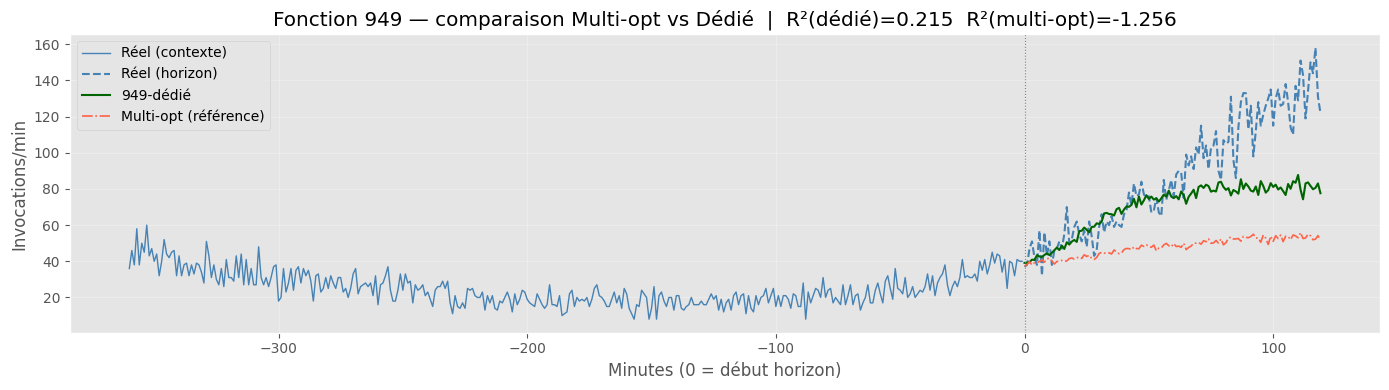

In [30]:
# Plot 949-dédié
fig, ax = plt.subplots(figsize=(14, 4))
n_ctx = 360
x_ctx = np.arange(-n_ctx, 0)
x_pred = np.arange(0, PREDICTION_LENGTH)
ax.plot(x_ctx,  np.array(test_949[0]['target'])[-(n_ctx + PREDICTION_LENGTH):-PREDICTION_LENGTH],
        color='steelblue', lw=1, label='Réel (contexte)')
ax.plot(x_pred, actual_949, color='steelblue', lw=1.5, ls='--', label='Réel (horizon)')
ax.plot(x_pred, pred_949,   color='darkgreen', lw=1.5, label='949-dédié')
ax.plot(x_pred, forecast_median_opt[0],
        color='tomato', lw=1.2, ls='-.', label='Multi-opt (référence)')
ax.axvline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Minutes (0 = début horizon)'); ax.set_ylabel('Invocations/min')
ax.set_title(f'Fonction 949 — comparaison Multi-opt vs Dédié  |  '
             f'R²(dédié)={r2_949:.3f}  R²(multi-opt)={opt_949.R2:.3f}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/ablation_949_plot.png', dpi=150); plt.show()

## 14 — Sauvegarde finale

In [31]:
final_summary = {
    'run_name': RUN_NAME, 'cluster': CLUSTER_ID, 'seed': SEED,
    'date': pd.Timestamp.now().isoformat(),
    'hpo': {
        'n_trials': len(study.trials),
        'n_completed': len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
        'n_pruned':    len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]),
        'best_params': study.best_params,
        'best_val_r2': float(study.best_value),
    },
    'final_training': {
        'epochs_trained': len(loss_history),
        'early_stopped': len(loss_history) < FINAL_MAX_EPOCHS,
        'best_val_r2': best_val_r2,
    },
    'test_metrics_optimized': df_metrics_opt[['MASE','sMAPE','RMSE','R2','Spearman']].mean().round(4).to_dict(),
    'test_metrics_fayam_reference': {
        'MASE': 1.2297, 'sMAPE': 0.2174, 'RMSE': 24.6507, 'R2': 0.3701, 'Spearman': 0.9195,
    },
    'ablation_949': ablation_summary,
}

with open(f'{DRIVE_BASE}/results/final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print('=' * 70)
print(f'Run complet — Cluster {CLUSTER_ID} (optimisé)')
print(f'Artefacts : {DRIVE_BASE}')
print('=' * 70)
print(json.dumps(final_summary, indent=2))

Run complet — Cluster 4 (optimisé)
Artefacts : /content/drive/MyDrive/m2-xai-faas/experiments/optimized-cluster4
{
  "run_name": "optimized-cluster4",
  "cluster": 4,
  "seed": 998,
  "date": "2026-05-14T16:41:21.326104",
  "hpo": {
    "n_trials": 15,
    "n_completed": 4,
    "n_pruned": 11,
    "best_params": {
      "d_model": 128,
      "context_length": 240,
      "encoder_layers": 4,
      "lr": 0.0006408870592758436
    },
    "best_val_r2": 0.5346918296533758
  },
  "final_training": {
    "epochs_trained": 14,
    "early_stopped": true,
    "best_val_r2": 0.48386599951805137
  },
  "test_metrics_optimized": {
    "MASE": 2.4141,
    "sMAPE": 0.5622,
    "RMSE": 48.1237,
    "R2": -1.3854,
    "Spearman": 0.8533
  },
  "test_metrics_fayam_reference": {
    "MASE": 1.2297,
    "sMAPE": 0.2174,
    "RMSE": 24.6507,
    "R2": 0.3701,
    "Spearman": 0.9195
  },
  "ablation_949": {
    "function_id": 949,
    "hyperparameters": {
      "d_model": 128,
      "context_length": 240,
